# Model 2 Inference — Model 1 Beats (360 Hz → 100 Hz)

Self-contained notebook: resample beats from Model 1 (360 Hz) to Model 2 (100 Hz), run CNN inference, plot and save results.

**No external scripts** — all logic is in this notebook.

## 1. Setup & paths

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.signal import resample, resample_poly
from sklearn.metrics import confusion_matrix, f1_score
from tqdm.auto import tqdm

# Paths (notebook lives in models/model2/notebooks/)
MODEL2_ROOT = Path.cwd().resolve()
if MODEL2_ROOT.name == "notebooks":
    MODEL2_ROOT = MODEL2_ROOT.parent
elif not (MODEL2_ROOT / "savedTrainedWeights").exists():
    MODEL2_ROOT = MODEL2_ROOT / "models" / "model2"

PROJECT_ROOT = MODEL2_ROOT.parents[1]
BEATS_360_PATH = PROJECT_ROOT / "data/processed/model2/X_model2_beats_from_model1.npy"
LABELS_PATH = PROJECT_ROOT / "data/processed/model2/y_model2_beats_from_model1.npy"
CNN_WEIGHTS_PATH = MODEL2_ROOT / "savedTrainedWeights/cnn_beat_classifier.pt"
REPORTS_DIR = MODEL2_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_LABELS = ["NORM", "MI", "HYP", "CD", "STTC"]
LABEL_TO_IDX = {c: i for i, c in enumerate(CLASS_LABELS)}

FS_MODEL1 = 360   # Hz — MIT-BIH / Model 1 pipeline
FS_MODEL2 = 100   # Hz — PTB-XL / Model 2 training
MODEL_INPUT_LEN = 70
CNN_DROPOUT = 0.5
BATCH_SIZE = 512
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Project root: {PROJECT_ROOT}")
print(f"Model 2 root: {MODEL2_ROOT}")
print(f"Device: {DEVICE}")

Project root: C:\Users\Dimi\Desktop\Uni Projects\Semester 4\Data Science Capstone Project\Project\ECG-Analysis-Pipeline
Model 2 root: C:\Users\Dimi\Desktop\Uni Projects\Semester 4\Data Science Capstone Project\Project\ECG-Analysis-Pipeline\models\model2
Device: cpu


## 2. Load Model 1 beats (360 Hz)

In [2]:
X_360 = np.load(BEATS_360_PATH)
print(f"Loaded beats @ {FS_MODEL1} Hz: {X_360.shape}, dtype={X_360.dtype}")
print(f"Sample range: [{X_360.min():.3f}, {X_360.max():.3f}]")

y_true = None
if LABELS_PATH.exists():
    y_true = np.load(LABELS_PATH)
    print(f"Labels found: {y_true.shape}")
else:
    print("No label file — inference only (no confusion matrix).")

Loaded beats @ 360 Hz: (185890, 70), dtype=float32
Sample range: [-13.859, 9.495]
No label file — inference only (no confusion matrix).


## 3. Resample 360 Hz → 100 Hz (mandatory)

Each beat is rate-converted with `resample_poly` (360→100) preserving duration, then resized to 70 samples to match Model 2 input.

In [3]:
def resample_beat_360_to_100hz(beat: np.ndarray) -> np.ndarray:
    """Convert one beat from Model 1 sampling (360 Hz) to Model 2 (100 Hz), length 70."""
    beat_100 = resample_poly(beat, FS_MODEL2, FS_MODEL1)
    if len(beat_100) != MODEL_INPUT_LEN:
        beat_100 = resample(beat_100, MODEL_INPUT_LEN)
    return beat_100.astype(np.float32)


def resample_all_beats(X: np.ndarray, batch_size: int = 5000) -> np.ndarray:
    out = np.empty((len(X), MODEL_INPUT_LEN), dtype=np.float32)
    for start in tqdm(range(0, len(X), batch_size), desc="Resampling 360→100 Hz"):
        end = min(start + batch_size, len(X))
        for i in range(start, end):
            out[i] = resample_beat_360_to_100hz(X[i])
    return out


# Preview one beat
preview = resample_beat_360_to_100hz(X_360[0])
print(f"Preview: {len(X_360[0])} samples @ {FS_MODEL1} Hz -> {len(preview)} samples @ {FS_MODEL2} Hz (model input)")

X_100 = resample_all_beats(X_360)
print(f"Resampled array for inference: {X_100.shape}")
assert X_100.shape[1] == MODEL_INPUT_LEN, "Model input length must be 70"

Preview: 70 samples @ 360 Hz -> 70 samples @ 100 Hz (model input)


Resampling 360→100 Hz:   0%|          | 0/38 [00:00<?, ?it/s]

Resampled array for inference: (185890, 70)


## 4. Load trained CNN & run inference

In [4]:
class BeatCNNClassifier(nn.Module):
    """Same architecture used in training (lightweight 1D CNN)."""

    def __init__(self, num_classes: int = 5, dropout: float = 0.5):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 17, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.conv_block(x))


model = BeatCNNClassifier(num_classes=5, dropout=CNN_DROPOUT)
model.load_state_dict(torch.load(CNN_WEIGHTS_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()
print(f"Loaded CNN weights from {CNN_WEIGHTS_PATH}")

X_cnn = X_100[:, np.newaxis, :]
all_preds = []
with torch.no_grad():
    for start in tqdm(range(0, len(X_cnn), BATCH_SIZE), desc="Inference"):
        batch = torch.tensor(X_cnn[start : start + BATCH_SIZE], dtype=torch.float32, device=DEVICE)
        logits = model(batch)
        all_preds.append(torch.argmax(logits, dim=1).cpu().numpy())

pred_idx = np.concatenate(all_preds)
predicted_classes = [CLASS_LABELS[i] for i in pred_idx]
print(f"Predictions: {len(predicted_classes):,} beats")

Loaded CNN weights from C:\Users\Dimi\Desktop\Uni Projects\Semester 4\Data Science Capstone Project\Project\ECG-Analysis-Pipeline\models\model2\savedTrainedWeights\cnn_beat_classifier.pt


Inference:   0%|          | 0/364 [00:00<?, ?it/s]

Predictions: 185,890 beats


## 5. Save predictions CSV

In [5]:
results_df = pd.DataFrame({
    "beat_index": np.arange(len(predicted_classes)),
    "predicted_class": predicted_classes,
})
if y_true is not None:
    results_df["true_class"] = y_true

predictions_path = REPORTS_DIR / "predictions.csv"
results_df.to_csv(predictions_path, index=False)
print(f"Saved -> {predictions_path}")
display(results_df.head(10))
display(results_df["predicted_class"].value_counts())

Saved -> C:\Users\Dimi\Desktop\Uni Projects\Semester 4\Data Science Capstone Project\Project\ECG-Analysis-Pipeline\models\model2\reports\predictions.csv


,beat_index,predicted_class
0,0,CD
1,1,CD
2,2,CD
3,3,CD
4,4,MI
5,5,MI
6,6,CD
7,7,CD
8,8,CD
9,9,CD


predicted_class
CD      95593
MI      84217
NORM     4367
STTC     1713
Name: count, dtype: int64

## 6. Plots

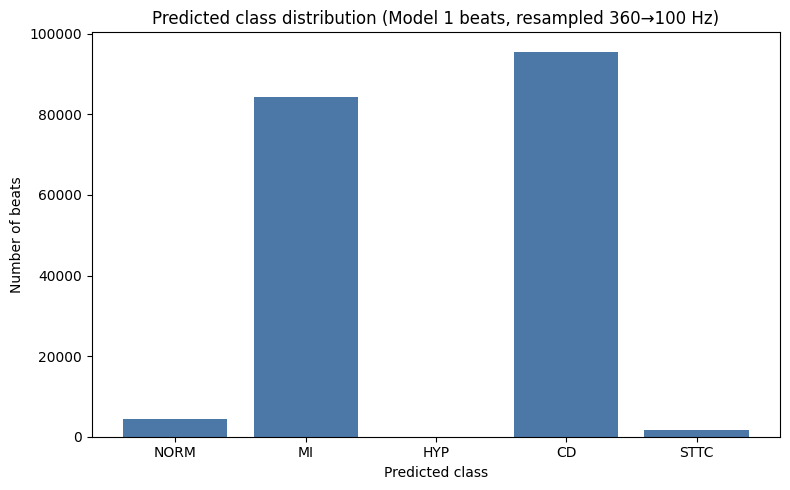

Saved -> C:\Users\Dimi\Desktop\Uni Projects\Semester 4\Data Science Capstone Project\Project\ECG-Analysis-Pipeline\models\model2\reports\predicted_class_distribution.png


In [6]:
counts = results_df["predicted_class"].value_counts().reindex(CLASS_LABELS, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(CLASS_LABELS, counts.values, color="#4C78A8")
ax.set_xlabel("Predicted class")
ax.set_ylabel("Number of beats")
ax.set_title(f"Predicted class distribution (Model 1 beats, resampled {FS_MODEL1}→{FS_MODEL2} Hz)")
fig.tight_layout()
dist_plot_path = REPORTS_DIR / "predicted_class_distribution.png"
fig.savefig(dist_plot_path, dpi=150)
plt.show()
print(f"Saved -> {dist_plot_path}")

In [7]:
if y_true is not None:
    y_true_idx = np.array([LABEL_TO_IDX[c] for c in y_true])
    cm = confusion_matrix(y_true_idx, pred_idx, labels=list(range(len(CLASS_LABELS))))
    macro_f1 = f1_score(y_true_idx, pred_idx, average="macro", zero_division=0)
    print(f"Macro F1 (with labels): {macro_f1:.4f}")

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm, cmap="Blues")
    fig.colorbar(im, ax=ax)
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xticklabels(CLASS_LABELS); ax.set_yticklabels(CLASS_LABELS)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title("Confusion matrix (Model 1 beats, resampled)")
    for i in range(5):
        for j in range(5):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    fig.tight_layout()
    cm_path = REPORTS_DIR / "confusion_matrix_model1_beats.png"
    fig.savefig(cm_path, dpi=150)
    plt.show()
    print(f"Saved -> {cm_path}")
else:
    print("Skipping confusion matrix — no ground-truth labels available.")

Skipping confusion matrix — no ground-truth labels available.


## 7. Resampling verification (before vs after)

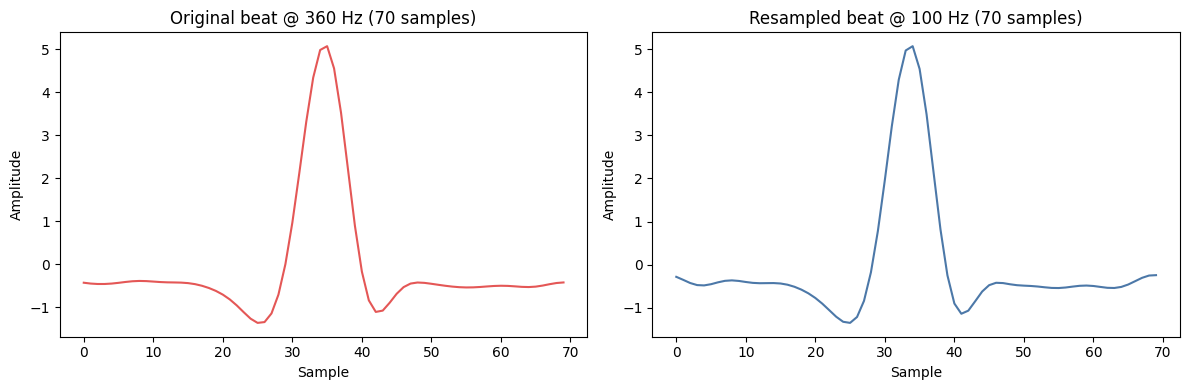

Saved -> C:\Users\Dimi\Desktop\Uni Projects\Semester 4\Data Science Capstone Project\Project\ECG-Analysis-Pipeline\models\model2\reports\resample_before_after.png

Done. All outputs in: C:\Users\Dimi\Desktop\Uni Projects\Semester 4\Data Science Capstone Project\Project\ECG-Analysis-Pipeline\models\model2\reports


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(X_360[0], color="#E45756")
axes[0].set_title(f"Original beat @ {FS_MODEL1} Hz ({len(X_360[0])} samples)")
axes[0].set_xlabel("Sample"); axes[0].set_ylabel("Amplitude")
axes[1].plot(X_100[0], color="#4C78A8")
axes[1].set_title(f"Resampled beat @ {FS_MODEL2} Hz ({len(X_100[0])} samples)")
axes[1].set_xlabel("Sample"); axes[1].set_ylabel("Amplitude")
fig.tight_layout()
wave_path = REPORTS_DIR / "resample_before_after.png"
fig.savefig(wave_path, dpi=150)
plt.show()
print(f"Saved -> {wave_path}")
print("\nDone. All outputs in:", REPORTS_DIR)